C:\Users\Avishek\AppData\Local\Temp\ipykernel_5876\270638232.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Value', data=df_box, palette='coolwarm')


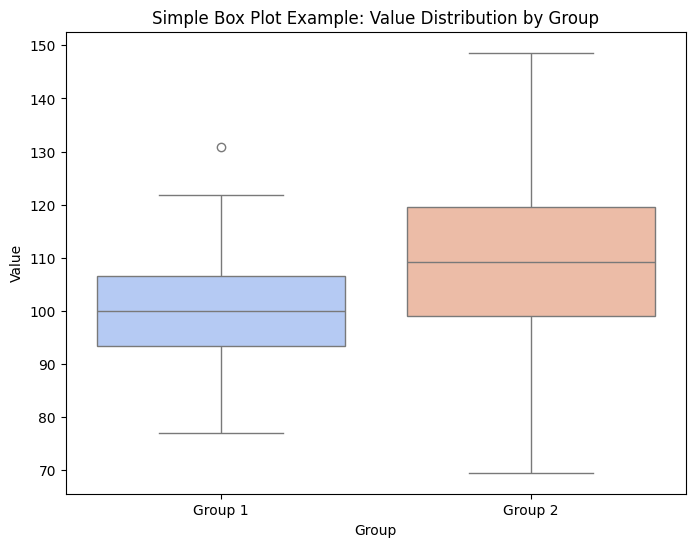

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Generate some example data for a box plot
# Let's create data for two different groups to compare their distributions
data1 = np.random.normal(loc=100, scale=10, size=200) # Group 1 centered around 100
data2 = np.random.normal(loc=110, scale=15, size=200) # Group 2 centered around 110 with more spread

# Combine the data into a pandas DataFrame for easier plotting with seaborn
df_box = pd.DataFrame({
    'Value': np.concatenate([data1, data2]),
    'Group': ['Group 1']*len(data1) + ['Group 2']*len(data2)
})

# Create the box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Group', y='Value', data=df_box, palette='coolwarm')

# Add labels and title
plt.title('Simple Box Plot Example: Value Distribution by Group')
plt.xlabel('Group')
plt.ylabel('Value')

plt.show()

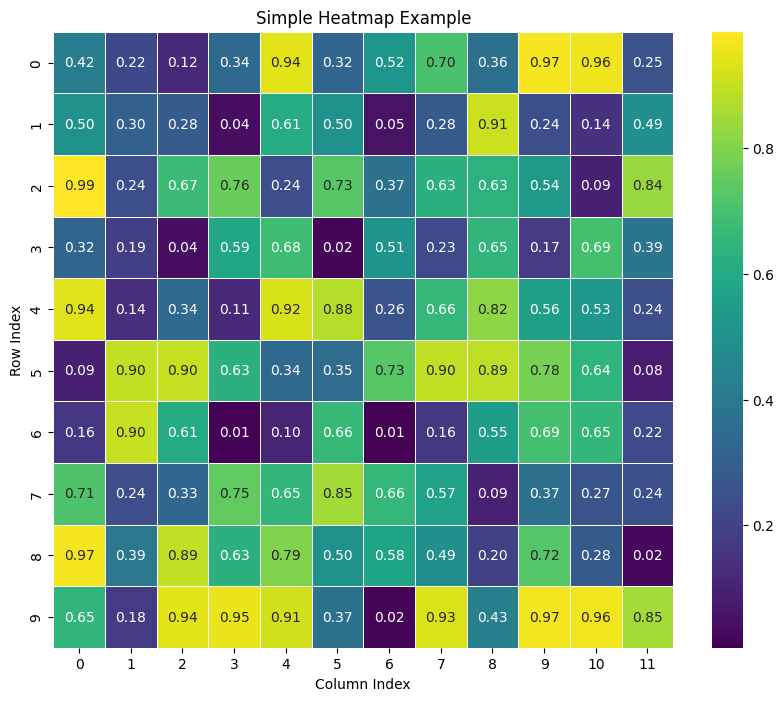

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Generate some random data for the heatmap
data = np.random.rand(10, 12) # 10 rows, 12 columns

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)

# Add labels and title
plt.title('Simple Heatmap Example')
plt.xlabel('Column Index')
plt.ylabel('Row Index')

plt.show()

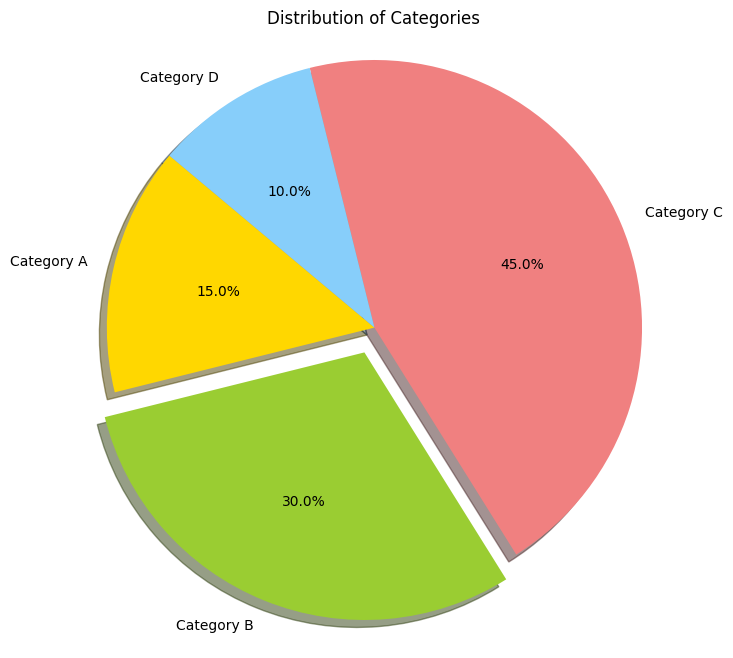

In [26]:
import matplotlib.pyplot as plt

# Data for the pie chart
labels = ['Category A', 'Category B', 'Category C', 'Category D']
sizes = [15, 30, 45, 10] # Proportions for each category
colors = ['gold', 'yellowgreen', 'lightcoral', 'lightskyblue']
explode = (0, 0.1, 0, 0)  # 'explode' the 2nd slice (Category B) a little

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)

plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Distribution of Categories')
plt.show()

Chart saved → car_manufacturer_piechart.png


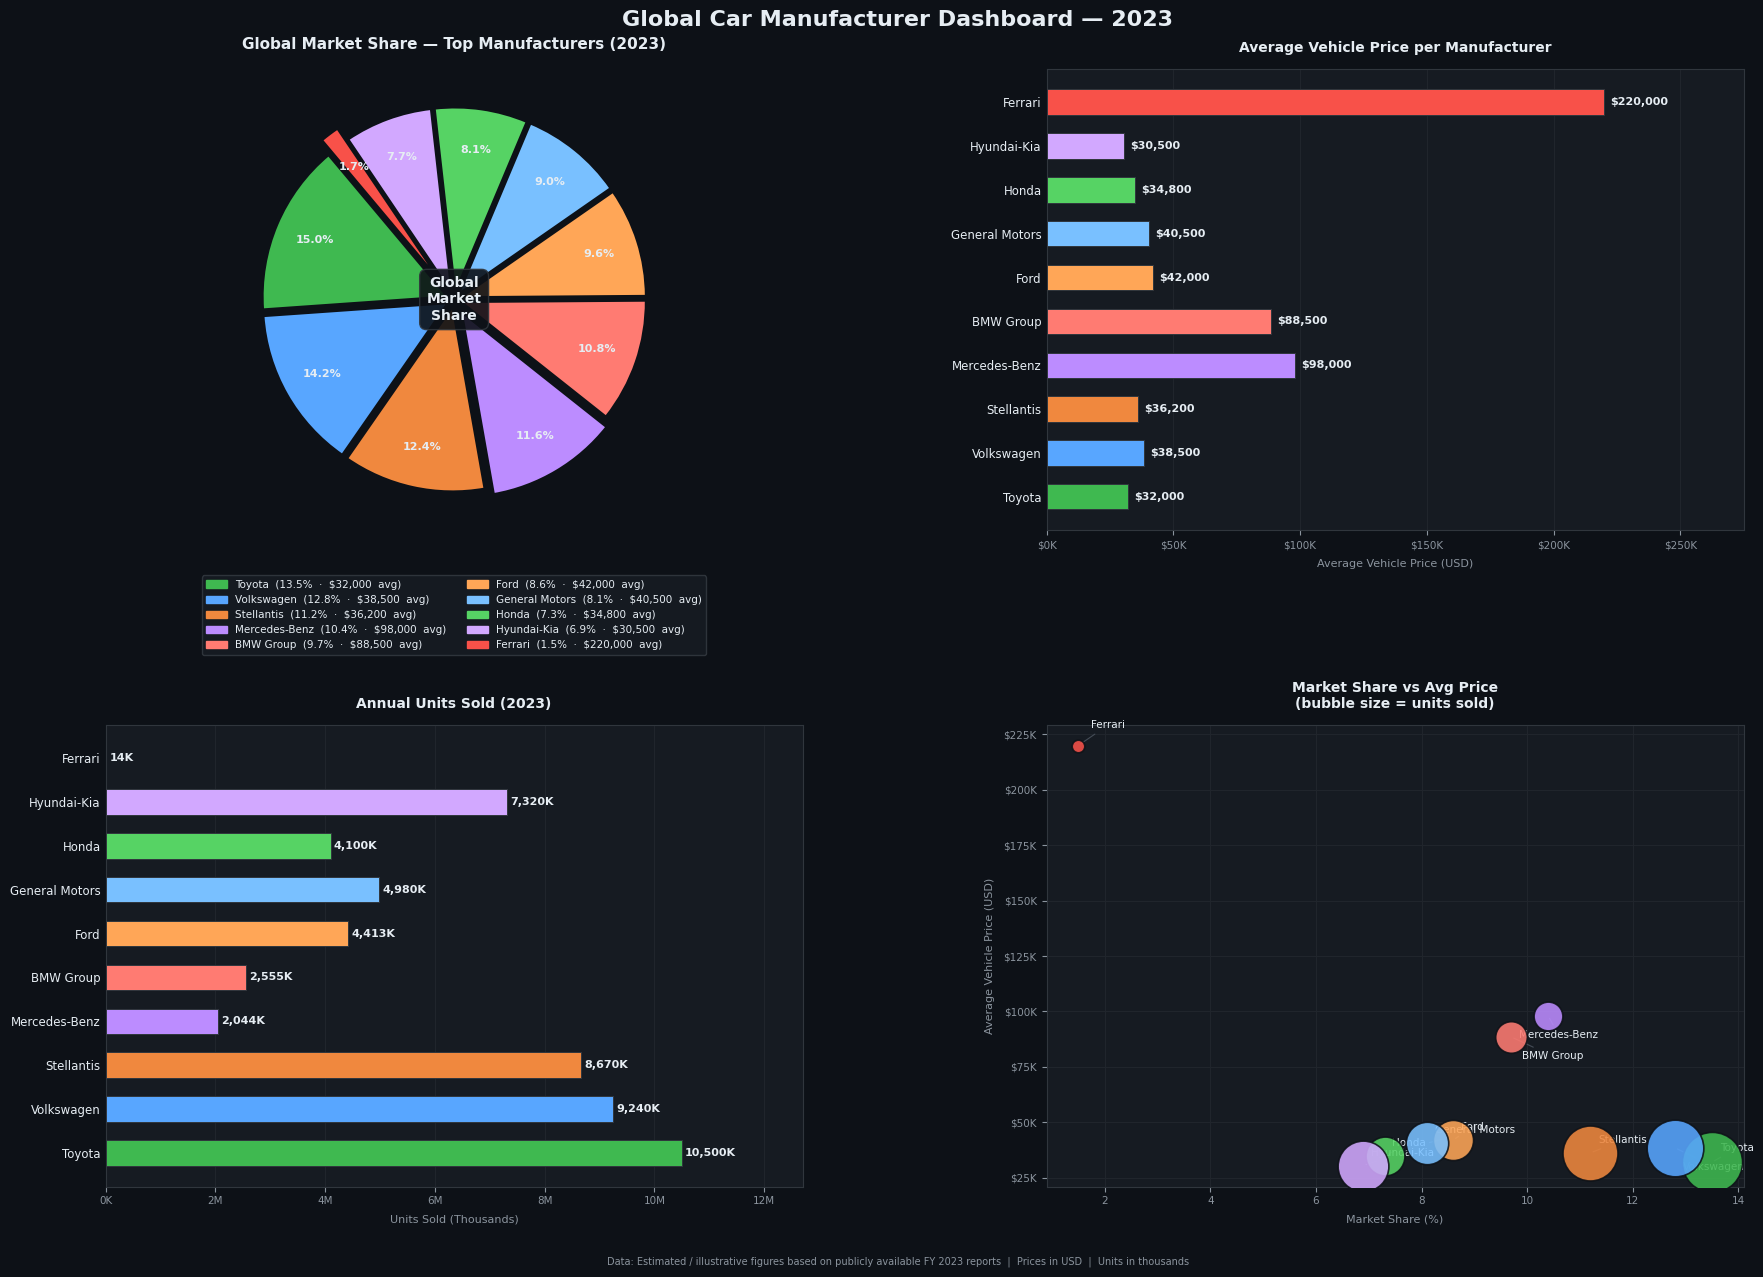

In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np

# ── Car Manufacturer Dataset: Global Market Share & Avg Price (2023) ───────

manufacturers = [
    "Toyota", "Volkswagen", "Stellantis", "Mercedes-Benz",
    "BMW Group", "Ford", "General Motors", "Honda",
    "Hyundai-Kia", "Ferrari"
]

# Global revenue share (%) – approximate FY 2023
market_share = [13.5, 12.8, 11.2, 10.4, 9.7, 8.6, 8.1, 7.3, 6.9, 1.5]

# Average vehicle price (USD) per manufacturer
avg_price = [
    32_000,   # Toyota
    38_500,   # Volkswagen
    36_200,   # Stellantis
    98_000,   # Mercedes-Benz
    88_500,   # BMW Group
    42_000,   # Ford
    40_500,   # General Motors
    34_800,   # Honda
    30_500,   # Hyundai-Kia
   220_000,   # Ferrari
]

# Annual units sold (thousands)
units_sold = [10_500, 9_240, 8_670, 2_044, 2_555,
               4_413, 4_980, 4_100, 7_320,    14]

colors = [
    "#3fb950",  # Toyota      – green
    "#58a6ff",  # Volkswagen  – blue
    "#f0883e",  # Stellantis  – orange
    "#bc8cff",  # Mercedes    – purple
    "#ff7b72",  # BMW         – coral
    "#ffa657",  # Ford        – amber
    "#79c0ff",  # GM          – sky
    "#56d364",  # Honda       – lime
    "#d2a8ff",  # Hyundai-Kia – lavender
    "#f85149",  # Ferrari     – red
]

explode = [0.04] * len(manufacturers)
explode[9] = 0.12   # pop Ferrari out more (luxury outlier)
explode[3] = 0.08   # pop Mercedes

# ══════════════════════════════════════════════════════════════════════════
# Figure layout: 2 rows × 2 cols
#   [0,0] Pie chart (main)       [0,1] Horizontal bar – Avg Price
#   [1,0] Horizontal bar – Units [1,1] Scatter – Price vs Share
# ══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 13))
fig.patch.set_facecolor("#0d1117")

gs = gridspec.GridSpec(2, 2, figure=fig,
                       hspace=0.42, wspace=0.35,
                       left=0.06, right=0.97,
                       top=0.93, bottom=0.07)

ax_pie  = fig.add_subplot(gs[0, 0])
ax_avgp = fig.add_subplot(gs[0, 1])
ax_unit = fig.add_subplot(gs[1, 0])
ax_scat = fig.add_subplot(gs[1, 1])

for ax in [ax_pie, ax_avgp, ax_unit, ax_scat]:
    ax.set_facecolor("#161b22")

# ══════════════════════════════════════════════════════════════════════════
# [0,0]  PIE CHART – Market Share
# ══════════════════════════════════════════════════════════════════════════
total_share = sum(market_share)

wedges, _, autotexts = ax_pie.pie(
    market_share,
    labels=None,
    autopct=lambda pct: f"{pct:.1f}%",
    startangle=130,
    explode=explode,
    colors=colors,
    wedgeprops=dict(linewidth=1.6, edgecolor="#0d1117"),
    pctdistance=0.78,
    shadow=False,
)

for at in autotexts:
    at.set_fontsize(8)
    at.set_fontweight("bold")
    at.set_color("#e6edf3")

# Centre label
ax_pie.text(0, 0, "Global\nMarket\nShare",
            ha="center", va="center",
            fontsize=10, fontweight="bold", color="#e6edf3",
            bbox=dict(boxstyle="round,pad=0.5",
                      facecolor="#0d1117", edgecolor="#30363d", alpha=0.9))

ax_pie.set_title("Global Market Share — Top Manufacturers (2023)",
                 fontsize=11, fontweight="bold", color="#e6edf3", pad=14)

# Legend
legend_handles = [
    mpatches.Patch(color=c,
                   label=f"{m}  ({s:.1f}%  ·  ${p:,}  avg)")
    for m, s, p, c in zip(manufacturers, market_share, avg_price, colors)
]
ax_pie.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.28),
    ncol=2,
    fontsize=7.5,
    facecolor="#161b22",
    edgecolor="#30363d",
    labelcolor="#e6edf3",
    framealpha=0.95,
)

# ══════════════════════════════════════════════════════════════════════════
# [0,1]  HORIZONTAL BAR – Average Vehicle Price
# ══════════════════════════════════════════════════════════════════════════
y = np.arange(len(manufacturers))
bars_p = ax_avgp.barh(y, avg_price, color=colors,
                      edgecolor="#30363d", linewidth=0.7,
                      height=0.58, zorder=3)

for bar, val in zip(bars_p, avg_price):
    ax_avgp.text(
        bar.get_width() + 2_500,
        bar.get_y() + bar.get_height() / 2,
        f"${val:,}",
        va="center", ha="left",
        fontsize=8, fontweight="bold", color="#e6edf3"
    )

ax_avgp.set_yticks(y)
ax_avgp.set_yticklabels(manufacturers, fontsize=8.5, color="#e6edf3")
ax_avgp.set_xlabel("Average Vehicle Price (USD)", fontsize=8,
                   color="#8b949e", labelpad=6)
ax_avgp.set_title("Average Vehicle Price per Manufacturer",
                  fontsize=10, fontweight="bold", color="#e6edf3", pad=12)
ax_avgp.set_xlim(0, max(avg_price) + 55_000)
ax_avgp.tick_params(axis="x", colors="#8b949e", labelsize=7.5)
ax_avgp.tick_params(axis="y", length=0)
ax_avgp.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"${v/1000:.0f}K"))
for sp in ax_avgp.spines.values():
    sp.set_edgecolor("#30363d")
ax_avgp.grid(axis="x", color="#21262d", linewidth=0.7, zorder=0)

# ══════════════════════════════════════════════════════════════════════════
# [1,0]  HORIZONTAL BAR – Units Sold
# ══════════════════════════════════════════════════════════════════════════
bars_u = ax_unit.barh(y, units_sold, color=colors,
                      edgecolor="#30363d", linewidth=0.7,
                      height=0.58, zorder=3)

for bar, val in zip(bars_u, units_sold):
    ax_unit.text(
        bar.get_width() + 60,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}K" if val >= 1000 else f"{val}K",
        va="center", ha="left",
        fontsize=8, fontweight="bold", color="#e6edf3"
    )

ax_unit.set_yticks(y)
ax_unit.set_yticklabels(manufacturers, fontsize=8.5, color="#e6edf3")
ax_unit.set_xlabel("Units Sold (Thousands)", fontsize=8,
                   color="#8b949e", labelpad=6)
ax_unit.set_title("Annual Units Sold (2023)",
                  fontsize=10, fontweight="bold", color="#e6edf3", pad=12)
ax_unit.set_xlim(0, max(units_sold) + 2_200)
ax_unit.tick_params(axis="x", colors="#8b949e", labelsize=7.5)
ax_unit.tick_params(axis="y", length=0)
ax_unit.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}M" if v >= 1000 else f"{v:.0f}K"))
for sp in ax_unit.spines.values():
    sp.set_edgecolor("#30363d")
ax_unit.grid(axis="x", color="#21262d", linewidth=0.7, zorder=0)

# ══════════════════════════════════════════════════════════════════════════
# [1,1]  SCATTER – Market Share vs Avg Price (bubble = units sold)
# ══════════════════════════════════════════════════════════════════════════
bubble_sizes = [u / max(units_sold) * 1800 + 80 for u in units_sold]

for i, (m, s, p, u, c, bs) in enumerate(
        zip(manufacturers, market_share, avg_price, units_sold, colors, bubble_sizes)):

    ax_scat.scatter(s, p, s=bs, color=c,
                    edgecolors="#0d1117", linewidth=1.2,
                    alpha=0.88, zorder=4)

    # Label offset tweaks to avoid overlap
    offsets = {
        "Ferrari":       ( 0.25,  8_000),
        "Mercedes-Benz": (-0.55, -10_000),
        "BMW Group":     ( 0.20, -10_000),
        "Toyota":        ( 0.15,  5_000),
        "Volkswagen":    ( 0.15, -10_000),
    }
    ox, oy = offsets.get(m, (0.15, 4_500))

    ax_scat.annotate(
        m,
        xy=(s, p),
        xytext=(s + ox, p + oy),
        fontsize=7.5, color="#e6edf3",
        arrowprops=dict(arrowstyle="-", color="#444c56", lw=0.8),
    )

ax_scat.set_xlabel("Market Share (%)", fontsize=8,
                   color="#8b949e", labelpad=6)
ax_scat.set_ylabel("Average Vehicle Price (USD)", fontsize=8,
                   color="#8b949e", labelpad=6)
ax_scat.set_title("Market Share vs Avg Price\n(bubble size = units sold)",
                  fontsize=10, fontweight="bold", color="#e6edf3", pad=12)

ax_scat.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"${v/1000:.0f}K"))
ax_scat.tick_params(axis="both", colors="#8b949e", labelsize=7.5)
for sp in ax_scat.spines.values():
    sp.set_edgecolor("#30363d")
ax_scat.grid(color="#21262d", linewidth=0.7, zorder=0)

# ── Master title & footnote ─────────────────────────────────────────────
fig.suptitle(
    "Global Car Manufacturer Dashboard — 2023",
    fontsize=16, fontweight="bold", color="#e6edf3", y=0.975
)
fig.text(
    0.5, 0.01,
    "Data: Estimated / illustrative figures based on publicly available FY 2023 reports  |  "
    "Prices in USD  |  Units in thousands",
    ha="center", fontsize=7, color="#8b949e"
)

plt.savefig("D:\\Downloads\\car_manufacturer_piechart.png",
            dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
print("Chart saved → car_manufacturer_piechart.png")
plt.show()

Chart saved → stock_piechart.png


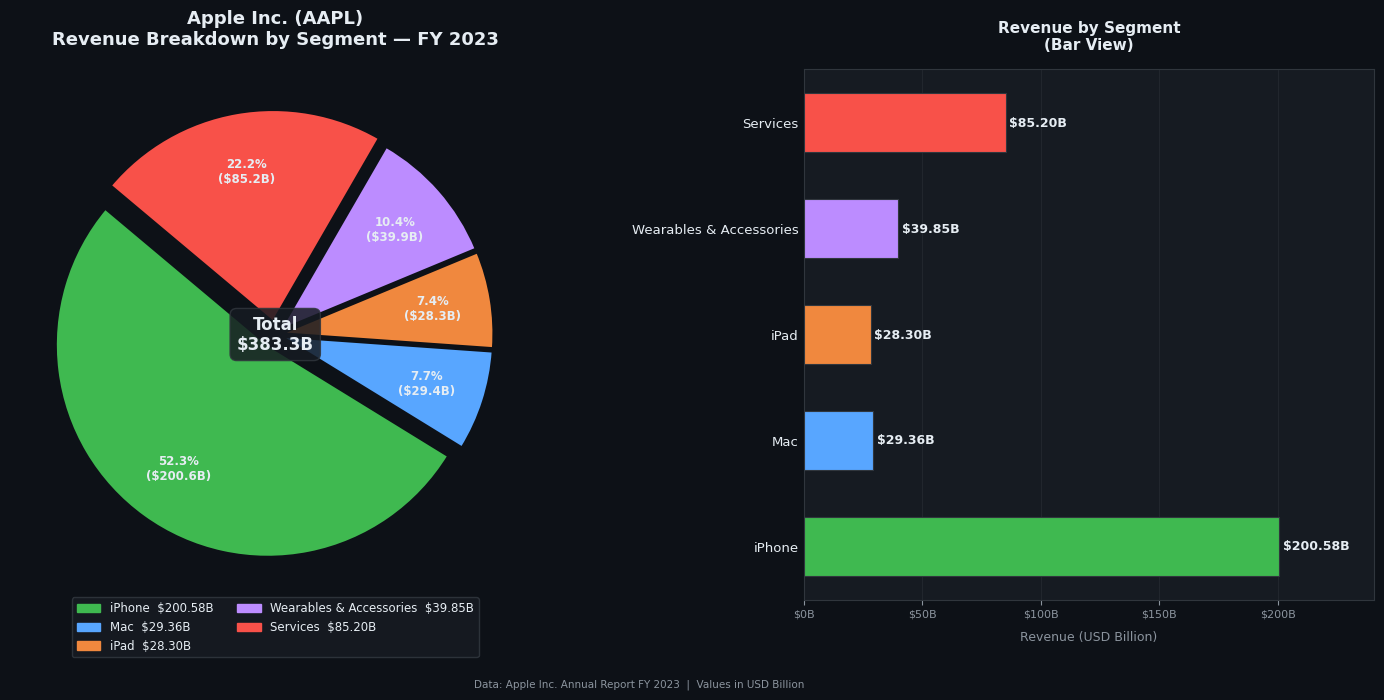

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Apple Inc. (AAPL) – Sector-wise Revenue Breakdown FY 2023 ─────────────
# Source: Apple Annual Report 2023 (approximate figures in $ Billion)

segments = [
    "iPhone",
    "Mac",
    "iPad",
    "Wearables\n& Accessories",
    "Services",
]

values = [200.58, 29.36, 28.30, 39.85, 85.20]   # in USD Billions

colors = [
    "#3fb950",   # green
    "#58a6ff",   # blue
    "#f0883e",   # orange
    "#bc8cff",   # purple
    "#f85149",   # red
]

explode = [0.06, 0.03, 0.03, 0.03, 0.06]        # pull iPhone & Services out

# ── Figure ─────────────────────────────────────────────────────────────────
fig, (ax_pie, ax_bar) = plt.subplots(
    1, 2, figsize=(15, 7),
    gridspec_kw={"width_ratios": [1.3, 1]}
)
fig.patch.set_facecolor("#0d1117")
ax_pie.set_facecolor("#0d1117")
ax_bar.set_facecolor("#161b22")

# ══════════════════════════════════════════════════════════════════════════
# LEFT – Pie chart
# ══════════════════════════════════════════════════════════════════════════
total = sum(values)

wedges, texts, autotexts = ax_pie.pie(
    values,
    labels=None,
    autopct=lambda pct: f"{pct:.1f}%\n(${pct/100*total:.1f}B)",
    startangle=140,
    explode=explode,
    colors=colors,
    wedgeprops=dict(linewidth=1.8, edgecolor="#0d1117"),
    pctdistance=0.72,
    shadow=False,
)

# Style the percentage / value labels inside slices
for at in autotexts:
    at.set_fontsize(8.5)
    at.set_fontweight("bold")
    at.set_color("#e6edf3")

# Centre donut-style label
ax_pie.text(0, 0, f"Total\n${total:.1f}B",
            ha="center", va="center",
            fontsize=12, fontweight="bold", color="#e6edf3",
            bbox=dict(boxstyle="round,pad=0.4",
                      facecolor="#161b22", edgecolor="#30363d", alpha=0.85))

ax_pie.set_title(
    "Apple Inc. (AAPL)\nRevenue Breakdown by Segment — FY 2023",
    fontsize=13, fontweight="bold", color="#e6edf3", pad=18
)

# Legend
legend_handles = [
    mpatches.Patch(color=c, label=f"{s.replace(chr(10),' ')}  ${v:.2f}B")
    for s, v, c in zip(segments, values, colors)
]
ax_pie.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    fontsize=8.5,
    facecolor="#161b22",
    edgecolor="#30363d",
    labelcolor="#e6edf3",
    framealpha=0.9,
)

# ══════════════════════════════════════════════════════════════════════════
# RIGHT – Horizontal bar chart (companion view)
# ══════════════════════════════════════════════════════════════════════════
y = np.arange(len(segments))
clean_labels = [s.replace("\n", " ") for s in segments]

bars = ax_bar.barh(y, values, color=colors,
                   edgecolor="#30363d", linewidth=0.8, height=0.55, zorder=3)

# Value labels at end of each bar
for bar, val in zip(bars, values):
    ax_bar.text(
        bar.get_width() + 1.5,
        bar.get_y() + bar.get_height() / 2,
        f"${val:.2f}B",
        va="center", ha="left",
        fontsize=9, fontweight="bold", color="#e6edf3"
    )

ax_bar.set_yticks(y)
ax_bar.set_yticklabels(clean_labels, fontsize=9.5, color="#e6edf3")
ax_bar.set_xlabel("Revenue (USD Billion)", fontsize=9, color="#8b949e", labelpad=8)
ax_bar.set_title("Revenue by Segment\n(Bar View)", fontsize=11,
                 fontweight="bold", color="#e6edf3", pad=14)

ax_bar.set_xlim(0, max(values) + 40)
ax_bar.tick_params(axis="x", colors="#8b949e", labelsize=8)
ax_bar.tick_params(axis="y", length=0)
ax_bar.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"${v:.0f}B")
)

for spine in ax_bar.spines.values():
    spine.set_edgecolor("#30363d")

ax_bar.grid(axis="x", color="#21262d", linewidth=0.8, zorder=0)

# ── Footnote ───────────────────────────────────────────────────────────────
fig.text(
    0.5, 0.01,
    "Data: Apple Inc. Annual Report FY 2023  |  Values in USD Billion",
    ha="center", fontsize=7.5, color="#8b949e"
)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("D:\\Downloads\\stock_piechart.png",
            dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
print("Chart saved → stock_piechart.png")
plt.show()

Chart saved → stock_histogram.png


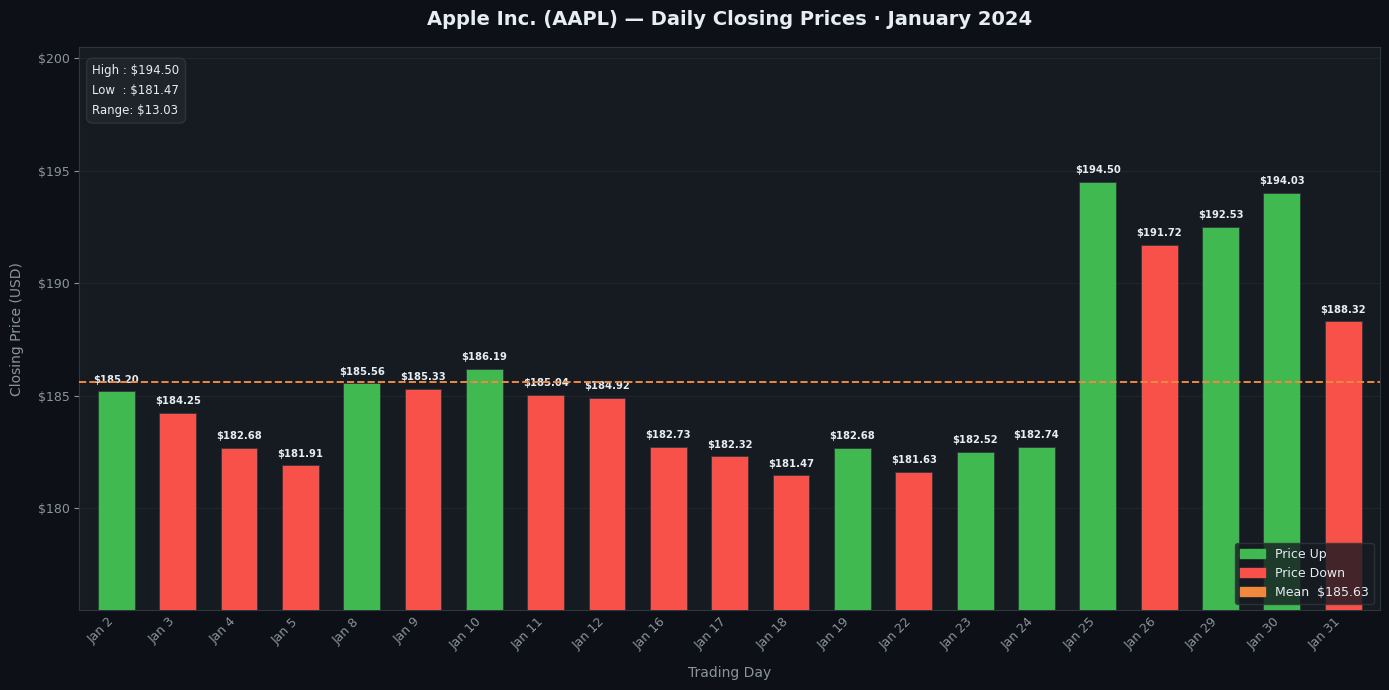

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Sample: Apple Inc. (AAPL) daily closing prices – Jan 2024 ──────────────
dates = [
    "Jan 2", "Jan 3", "Jan 4", "Jan 5", "Jan 8",
    "Jan 9", "Jan 10", "Jan 11", "Jan 12", "Jan 16",
    "Jan 17", "Jan 18", "Jan 19", "Jan 22", "Jan 23",
    "Jan 24", "Jan 25", "Jan 26", "Jan 29", "Jan 30",
    "Jan 31",
]

prices = [
    185.20, 184.25, 182.68, 181.91, 185.56,
    185.33, 186.19, 185.04, 184.92, 182.73,
    182.32, 181.47, 182.68, 181.63, 182.52,
    182.74, 194.50, 191.72, 192.53, 194.03,
    188.32,
]

# ── Figure layout ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#161b22")

# ── Bar colours: green if price rose, red if it fell ──────────────────────
colors = []
for i, p in enumerate(prices):
    if i == 0:
        colors.append("#3fb950")          # first bar → green by default
    elif p >= prices[i - 1]:
        colors.append("#3fb950")          # up  → green
    else:
        colors.append("#f85149")          # down → red

x = np.arange(len(dates))
bars = ax.bar(x, prices, color=colors, width=0.6,
              edgecolor="#30363d", linewidth=0.6, zorder=3)

# ── Value labels on top of every bar ──────────────────────────────────────
for bar, price in zip(bars, prices):
    ax.text(
        bar.get_x() + bar.get_width() / 2,   # x centre
        bar.get_height() + 0.30,              # just above the bar
        f"${price:.2f}",
        ha="center", va="bottom",
        fontsize=7.2, fontweight="bold",
        color="#e6edf3",
    )

# ── Reference line: mean price ─────────────────────────────────────────────
mean_price = np.mean(prices)
ax.axhline(mean_price, color="#f0883e", linewidth=1.4,
           linestyle="--", zorder=4, label=f"Mean  ${mean_price:.2f}")

# ── Axes styling ───────────────────────────────────────────────────────────
ax.set_xlim(-0.6, len(dates) - 0.4)
ax.set_ylim(min(prices) - 6, max(prices) + 6)

ax.set_xticks(x)
ax.set_xticklabels(dates, rotation=45, ha="right",
                   fontsize=9, color="#8b949e")

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:.0f}"))
ax.tick_params(axis="y", colors="#8b949e", labelsize=9)
ax.tick_params(axis="x", length=0)

for spine in ax.spines.values():
    spine.set_edgecolor("#30363d")

ax.grid(axis="y", color="#21262d", linewidth=0.8, zorder=0)

# ── Titles & labels ────────────────────────────────────────────────────────
ax.set_title("Apple Inc. (AAPL) — Daily Closing Prices · January 2024",
             fontsize=14, fontweight="bold", color="#e6edf3", pad=16)
ax.set_xlabel("Trading Day", fontsize=10, color="#8b949e", labelpad=10)
ax.set_ylabel("Closing Price (USD)", fontsize=10, color="#8b949e", labelpad=10)

# ── Legend ─────────────────────────────────────────────────────────────────
up_patch   = mpatches.Patch(color="#3fb950", label="Price Up")
down_patch = mpatches.Patch(color="#f85149", label="Price Down")
mean_line  = mpatches.Patch(color="#f0883e", label=f"Mean  ${mean_price:.2f}")

ax.legend(handles=[up_patch, down_patch, mean_line],
          loc="lower right", fontsize=9,
          facecolor="#161b22", edgecolor="#30363d",
          labelcolor="#e6edf3")

# ── Summary stats (text box) ───────────────────────────────────────────────
stats = (
    f"High : ${max(prices):.2f}\n"
    f"Low  : ${min(prices):.2f}\n"
    f"Range: ${max(prices)-min(prices):.2f}"
)
ax.text(0.01, 0.97, stats,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=8.5, color="#e6edf3",
        linespacing=1.7,
        bbox=dict(boxstyle="round,pad=0.5",
                  facecolor="#21262d", edgecolor="#30363d", alpha=0.9))

plt.tight_layout()
plt.savefig("D:\\Downloads\\stock_histogram.png",
            dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
print("Chart saved → stock_histogram.png")
plt.show()


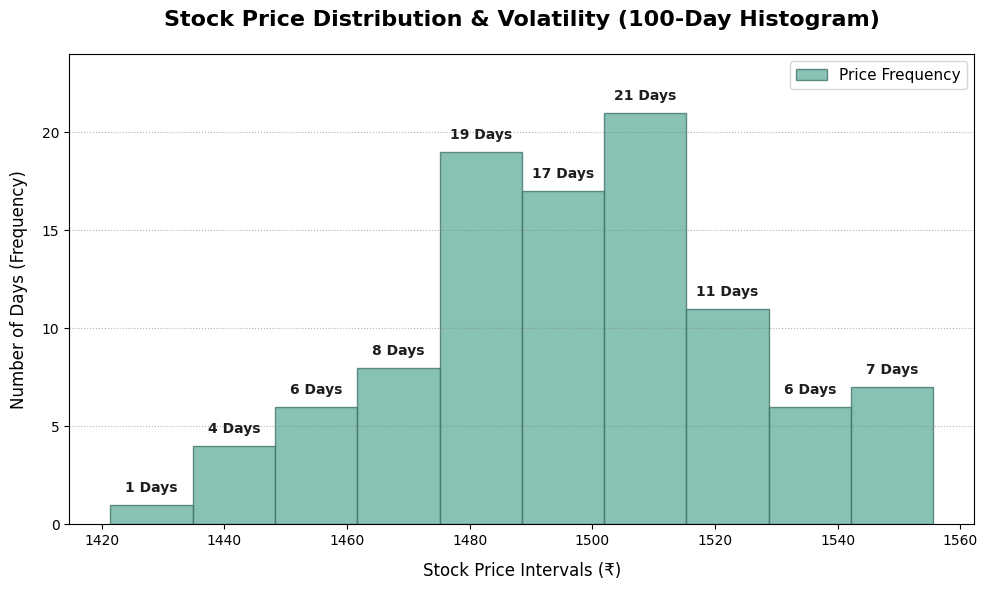

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Simulate Stock Data (e.g., 100 days of a volatile stock trading around ₹1500)
np.random.seed(42)
stock_prices = np.random.normal(loc=1500, scale=30, size=100) 

# 2. Initialize the plot
plt.figure(figsize=(10, 6))

# 3. Create the Histogram
# 'bins' defines how many intervals we break the data into
counts, bins, patches = plt.hist(stock_prices, 
                                 bins=10, 
                                 color='#69b3a2', 
                                 edgecolor='#43746a', 
                                 alpha=0.8, 
                                 label='Price Frequency')

# 4. Loop to show the frequency count value on top of every single bin
for patch in patches:
    height = patch.get_height()
    if height > 0: # Only label bins that actually have data points in them
        plt.text(patch.get_x() + patch.get_width()/2.0,   # X coordinate: center of the bin
                 height + 0.5,                            # Y coordinate: just above the bin top
                 f'{int(height)} Days',                   # Text formatting
                 ha='center',                             # Horizontal alignment
                 va='bottom',                             # Vertical alignment
                 fontsize=10,
                 fontweight='bold',
                 color='#1e1e1e')

# 5. Styling and Customization
plt.title("Stock Price Distribution & Volatility (100-Day Histogram)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Stock Price Intervals (₹)", fontsize=12, labelpad=10)
plt.ylabel("Number of Days (Frequency)", fontsize=12, labelpad=10)

# Add a clean horizontal grid to track frequencies easily
plt.grid(True, axis='y', linestyle=':', alpha=0.6, color='gray')

# Make the Y-axis limit slightly taller than the highest bin to make room for labels
plt.ylim(0, max(counts) + 3)

# Add the legend
plt.legend(loc='upper right', fontsize=11)

# 6. Display the chart smoothly
plt.tight_layout()
plt.show()

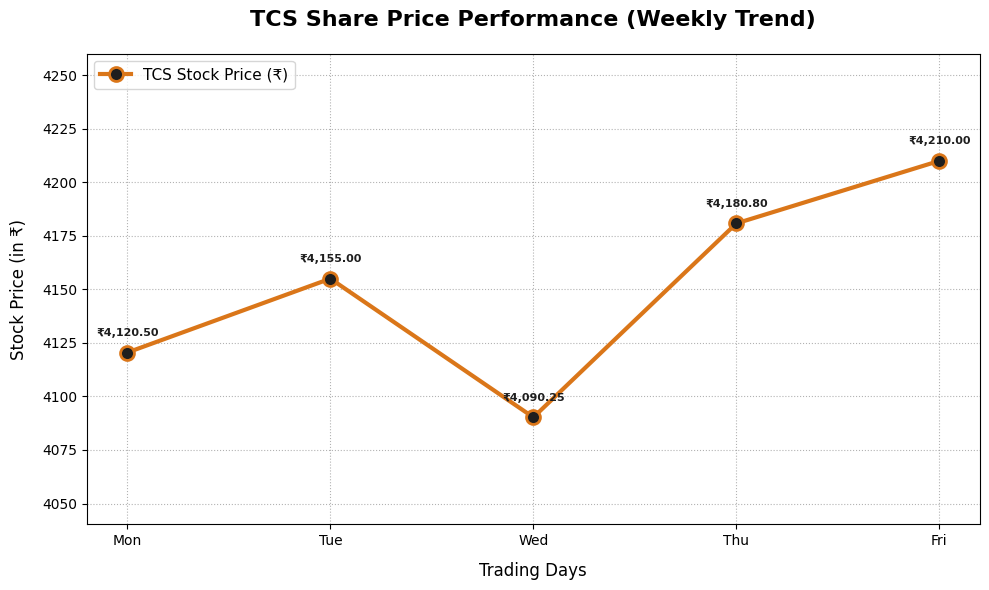

In [12]:
import matplotlib.pyplot as plt

# 1. Prepare Stock Data (Simulating TCS stock over a week)
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
stock_prices = [4120.50, 4155.00, 4090.25, 4180.80, 4210.00]

# 2. Initialize the plot
plt.figure(figsize=(10, 6))

# 3. Plot the line chart
plt.plot(days, stock_prices, 
         color="#da7619",       # Emerald green commonly used for positive stock trends
         linestyle='-',         # Solid line
         linewidth=3,           # Thick line for easy viewing
         marker='o',            # Round markers at each day
         markersize=10,         # Large markers
         markerfacecolor='#1e1e1e', # Dark center for the marker
         markeredgewidth=2,     # Border width for the marker
         label='TCS Stock Price (₹)')

# 4. Loop to show values at *every single point*
for i, price in enumerate(stock_prices):
    plt.annotate(f"₹{price:,.2f}", 
                 (days[i], stock_prices[i]), 
                 textcoords="offset points", 
                 xytext=(0, 12),       # Places text 12 points directly above the marker
                 ha='center',          # Centers text horizontally over the marker
                 fontsize=8, 
                 fontweight='bold',
                 color='#1e1e1e')      # Clean dark font for readability

# 5. Styling the Dashboard
plt.title("TCS Share Price Performance (Weekly Trend)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Trading Days", fontsize=12, labelpad=10)
plt.ylabel("Stock Price (in ₹)", fontsize=12, labelpad=10)

# Expand the y-axis limits slightly so the top annotations don't cut off
plt.ylim(min(stock_prices) - 50, max(stock_prices) + 50)

# Add a subtle grid
plt.grid(True, linestyle=':', alpha=0.6, color='gray')

# Add the legend
plt.legend(loc='upper left', fontsize=11)

# 6. Smooth rendering display
plt.tight_layout()
plt.show()

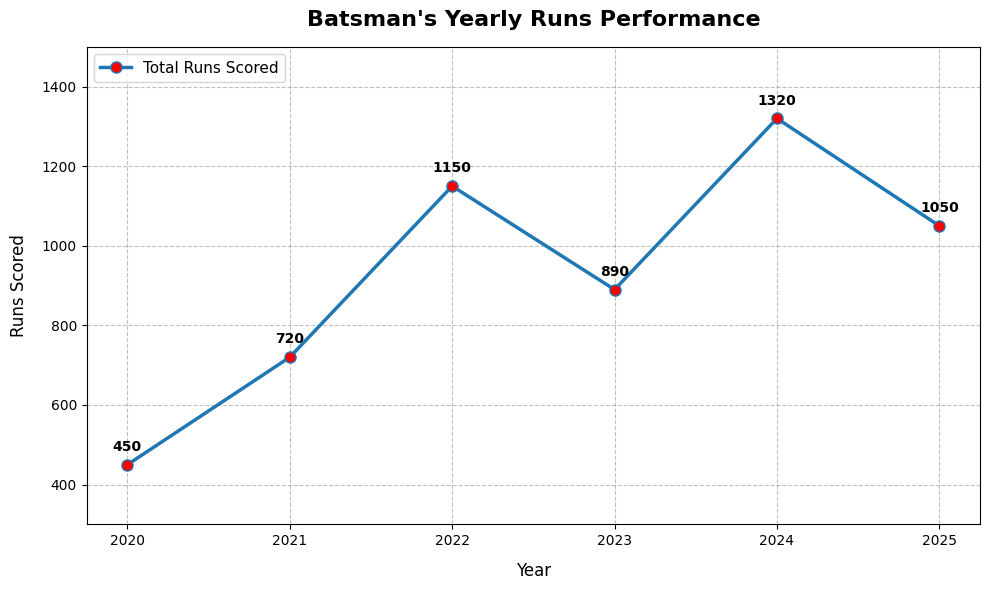

In [3]:
import matplotlib.pyplot as plt

# 1. Prepare the Data
years = [2020, 2021, 2022, 2023, 2024, 2025]
runs = [450, 720, 1150, 890, 1320, 1050]

# 2. Initialize the plot with a clean, professional size
plt.figure(figsize=(10, 6))

# 3. Plot the line chart
# 'marker=o' adds circles at data points, 'ls=-' makes it a solid line
plt.plot(years, runs, 
         color='#1f77b4',       # Clean cricket-jersey blue
         linestyle='-',         # Solid line
         linewidth=2.5,         # Thicker line for visibility
         marker='o',            # Circle markers
         markersize=8,          # Distinct marker size
         markerfacecolor='red', # Red markers to resemble a cricket ball
         label='Total Runs Scored')

# 4. Add data labels on top of each marker
for i, txt in enumerate(runs):
    plt.annotate(f"{txt}", 
                 (years[i], runs[i]), 
                 textcoords="offset points", 
                 xytext=(0,10),        # 10 points text offset above the marker
                 ha='center',          # Center horizontally
                 fontsize=10, 
                 fontweight='bold')

# 5. Labels, Title, and Aesthetics
plt.title("Batsman's Yearly Runs Performance", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Year", fontsize=12, labelpad=10)
plt.ylabel("Runs Scored", fontsize=12, labelpad=10)

# Customize the axes ticks to only show our specific years
plt.xticks(years)

# Set the y-axis range slightly higher than max runs to leave room for the top label
plt.ylim(300, 1500)

# Add a subtle grid background
plt.grid(True, linestyle='--', alpha=0.5, color='gray')

# Add a legend
plt.legend(loc='upper left', fontsize=11)

# 6. Display the chart smoothly
plt.tight_layout()
plt.show()

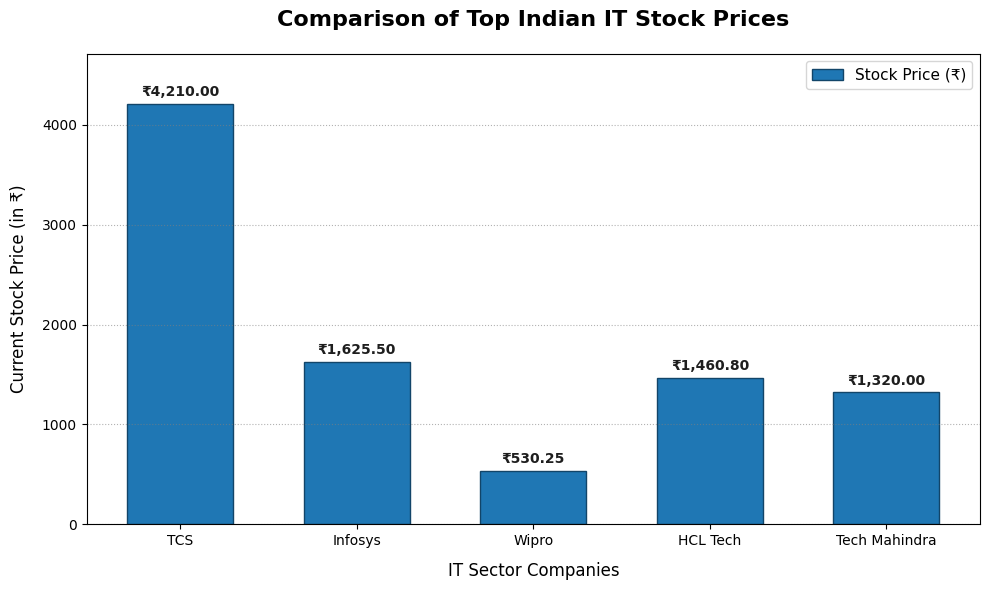

In [13]:
import matplotlib.pyplot as plt

# 1. Prepare Stock Data (Closing prices in ₹ for top Indian IT stocks)
stocks = ['TCS', 'Infosys', 'Wipro', 'HCL Tech', 'Tech Mahindra']
stock_prices = [4210.00, 1625.50, 530.25, 1460.80, 1320.00]

# 2. Initialize the plot
plt.figure(figsize=(10, 6))

# 3. Create the Bar Chart
# 'color' applies a nice corporate blue palette, 'edgecolor' cleans up the borders
bars = plt.bar(stocks, stock_prices, 
               color='#1f77b4', 
               edgecolor='#124569', 
               width=0.6,
               label='Stock Price (₹)')

# 4. Loop to show values at *every single point* (on top of each bar)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0,  # X coordinate: center of the bar
             yval + 50,                          # Y coordinate: slightly above the top of the bar
             f"₹{yval:,.2f}",                    # Formatted text string
             ha='center',                        # Horizontal alignment
             va='bottom',                        # Vertical alignment
             fontsize=10, 
             fontweight='bold',
             color='#1e1e1e')

# 5. Styling and Customization
plt.title("Comparison of Top Indian IT Stock Prices", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("IT Sector Companies", fontsize=12, labelpad=10)
plt.ylabel("Current Stock Price (in ₹)", fontsize=12, labelpad=10)

# Set the y-axis range higher than the maximum price to make room for the highest text label
plt.ylim(0, max(stock_prices) + 500)

# Add a subtle horizontal grid (axis='y' ensures lines don't run vertically through the bars)
plt.grid(True, axis='y', linestyle=':', alpha=0.6, color='gray')

# Add the legend
plt.legend(loc='upper right', fontsize=11)

# 6. Adjust layout and show the chart
plt.tight_layout()
plt.show()

Matplotlib is building the font cache; this may take a moment.


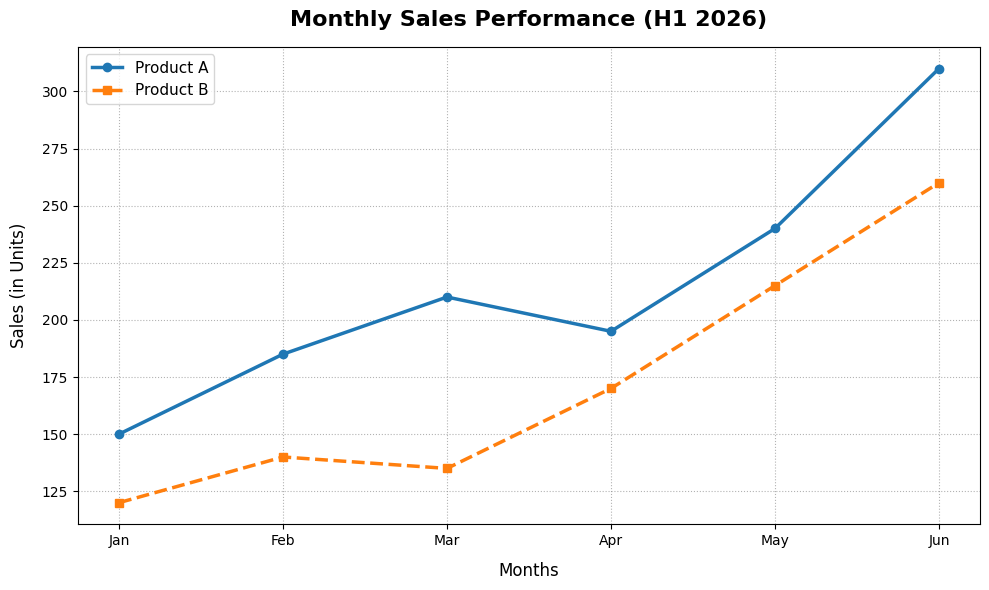

In [2]:
import matplotlib.pyplot as plt

# 1. Prepare the data
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
product_a_sales = [150, 185, 210, 195, 240, 310]
product_b_sales = [120, 140, 135, 170, 215, 260]

# 2. Create the figure and plot the data
plt.figure(figsize=(10, 6))  # Sets the window width and height in inches

# Plot Product A (Solid blue line with circle markers)
plt.plot(months, product_a_sales, 
         label='Product A', 
         color='#1f77b4', 
         linestyle='-', 
         marker='o', 
         linewidth=2.5)

# Plot Product B (Dashed orange line with square markers)
plt.plot(months, product_b_sales, 
         label='Product B', 
         color='#ff7f0e', 
         linestyle='--', 
         marker='s', 
         linewidth=2.5)

# 3. Add styling and labels
plt.title('Monthly Sales Performance (H1 2026)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Months', fontsize=12, labelpad=10)
plt.ylabel('Sales (in Units)', fontsize=12, labelpad=10)

# Add a grid to make the values easier to read
plt.grid(True, linestyle=':', alpha=0.6, color='gray')

# Add a legend to identify the lines
plt.legend(fontsize=11, loc='upper left')

# 4. Display the chart
plt.tight_layout()  # Adjusts spacing so labels don't get cut off
plt.show()